## Función Generadora de Momentos (MGF)

### 📊 Definición

$$M_X(t) = \mathbb{E}[e^{tX}] = \begin{cases}
\sum_{x} e^{tx} P(X=x) & \text{(discreta)} \\
\int_{-\infty}^{\infty} e^{tx} f(x) dx & \text{(continua)}
\end{cases}$$

### 🎯 Propósito

La MGF **genera todos los momentos** de una distribución:

$$\mathbb{E}[X^n] = M_X^{(n)}(0) = \frac{d^n}{dt^n} M_X(t) \bigg|_{t=0}$$

### 📝 Ejemplos de MGF

| Distribución | MGF $M_X(t)$ | Dominio |
|--------------|--------------|---------|
| **Bernoulli(p)** | $1-p + pe^t$ | $\forall t$ |
| **Binomial(n, p)** | $(1-p + pe^t)^n$ | $\forall t$ |
| **Poisson(λ)** | $e^{\lambda(e^t - 1)}$ | $\forall t$ |
| **Exponencial(λ)** | $\frac{\lambda}{\lambda - t}$ | $t < \lambda$ |
| **Normal(μ, σ²)** | $e^{\mu t + \frac{1}{2}\sigma^2 t^2}$ | $\forall t$ |

### 🔑 Propiedades importantes

1. **Unicidad:** Si dos distribuciones tienen la misma MGF (en un intervalo), son idénticas.
2. **Suma de independientes:** $M_{X+Y}(t) = M_X(t) \cdot M_Y(t)$
3. **Transformación lineal:** $M_{aX+b}(t) = e^{bt} M_X(at)$

### 💡 ¿Por qué es útil?

- **Identificar distribuciones** (unicidad)
- **Calcular momentos** (derivando)
- **Demostrar el TCL** (teorema central del límite)
- **Trabajar con sumas** de variables independientes

interactive(children=(Dropdown(description='Distribución:', options=('Normal', 'Exponencial', 'Poisson', 'Bino…

<function __main__.demostracion_mgf(distribucion='Normal', mu=0, sigma=1, lamb=3, n=10, p=0.5, t_max=2)>

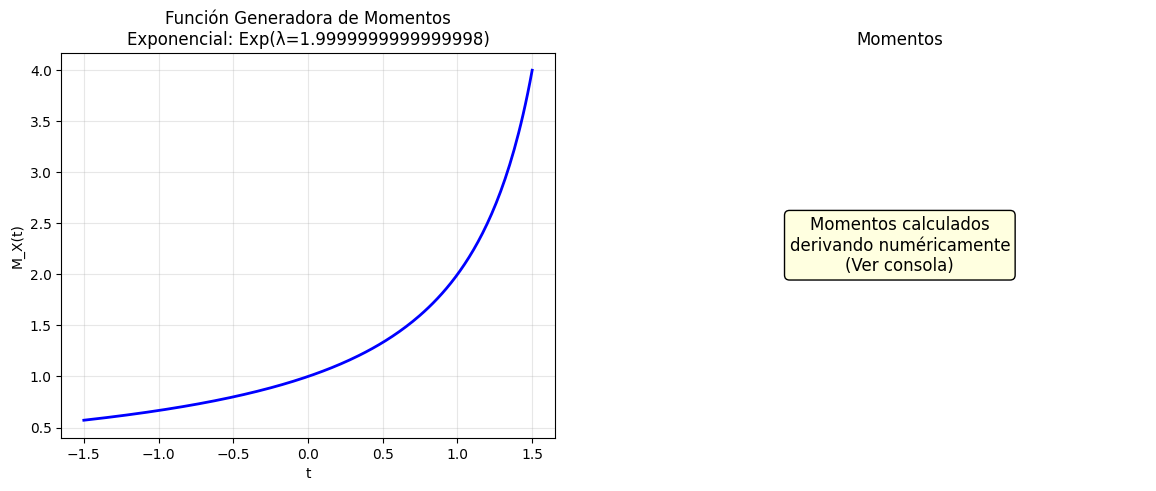

In [4]:
# Función Generadora de Momentos - Demostración
# En lugar de from scipy.misc import derivative
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets
# Eliminamos la importación de derivative que fallaba
def mgf_normal(t, mu=0, sigma=1):
    """MGF de la distribución Normal"""
    return np.exp(mu*t + 0.5*sigma**2*t**2)

#def mgf_exponencial(t, lamb=1):
#    """MGF de la distribución Exponencial"""
#    return lamb/(lamb - t) if t < lamb else np.inf

def mgf_exponencial(t, lamb=1):
    """MGF de la distribución Exponencial optimizada para arreglos"""
    # np.where(condición, valor_si_es_cierto, valor_si_es_falso)
    return np.where(t < lamb, lamb / (lamb - t), np.inf)

def mgf_poisson(t, lamb=1):
    """MGF de la distribución Poisson"""
    return np.exp(lamb*(np.exp(t) - 1))

def mgf_binomial(t, n=10, p=0.5):
    """MGF de la distribución Binomial"""
    return (1 - p + p*np.exp(t))**n

def demostracion_mgf(distribucion="Normal", mu=0, sigma=1, lamb=3, n=10, p=0.5, t_max=2):
    """
    Demostración de la Función Generadora de Momentos
    """
    t_vals = np.linspace(-t_max, t_max, 200)
    
    # Seleccionar MGF
    if distribucion == "Normal":
        mgf = mgf_normal(t_vals, mu, sigma)
        titulo = f'N({mu}, {sigma}²)'
        momentos_teoricos = [mu, sigma**2, 0, 3*sigma**4]
    elif distribucion == "Exponencial":
        t_vals = t_vals[t_vals < lamb]
        mgf = mgf_exponencial(t_vals, lamb)
        titulo = f'Exp(λ={lamb})'
    elif distribucion == "Poisson":
        mgf = mgf_poisson(t_vals, lamb)
        titulo = f'Poisson(λ={lamb})'
    else:  # Binomial
        mgf = mgf_binomial(t_vals, n, p)
        titulo = f'Bin(n={n}, p={p})'
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: MGF
    axes[0].plot(t_vals, mgf, 'b-', linewidth=2)
    axes[0].set_xlabel('t')
    axes[0].set_ylabel('M_X(t)')
    axes[0].set_title(f'Función Generadora de Momentos\n{distribucion}: {titulo}', fontsize=12)
    axes[0].grid(alpha=0.3)
    
    # Calcular momentos derivando numéricamente
    if distribucion == "Normal":
        # Derivadas analíticas
        momentos = []
        for k in range(1, 5):
            if k == 1:
                momentos.append(mu)
            elif k == 2:
                momentos.append(mu**2 + sigma**2)
            elif k == 3:
                momentos.append(mu**3 + 3*mu*sigma**2)
            else:
                momentos.append(mu**4 + 6*mu**2*sigma**2 + 3*sigma**4)
        
        etiquetas = [f'μ₁ = E[X]', f'μ₂ = E[X²]', f'μ₃ = E[X³]', f'μ₄ = E[X⁴]']
        
        # Gráfico 2: Momentos
        axes[1].bar(etiquetas, momentos, color='lightgreen', edgecolor='black')
        axes[1].set_title('Momentos (no centrados)', fontsize=12)
        axes[1].set_ylabel('Valor')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(axis='y', alpha=0.3)
        
        # Mostrar derivadas en consola
        print("\n📊 Momentos calculados:")
        for i, (label, mom) in enumerate(zip(etiquetas, momentos), 1):
            print(f"  {label} = {mom:.4f}")
            
        print(f"\n📌 Verificación:")
        print(f"  Media (E[X]) = {mu}")
        print(f"  Varianza = E[X²] - (E[X])² = {momentos[1]} - {momentos[0]}² = {momentos[1] - momentos[0]**2:.4f}")
        print(f"  (Debe ser σ² = {sigma**2})")
    
    else:
        axes[1].text(0.5, 0.5, 'Momentos calculados\nderivando numéricamente\n(Ver consola)', 
                    ha='center', va='center', transform=axes[1].transAxes,
                    fontsize=12, bbox=dict(boxstyle='round', facecolor='lightyellow'))
        axes[1].set_title('Momentos', fontsize=12)
        axes[1].axis('off')
        
        # Derivación numérica en t=0
        def mgf_func(t):
            if distribucion == "Exponencial":
                return mgf_exponencial(t, lamb)
            elif distribucion == "Poisson":
                return mgf_poisson(t, lamb)
            else:
                return mgf_binomial(t, n, p)
        
        print("\n📊 Momentos calculados (derivación numérica en t=0):")
        for k in range(1, 5):
            momento = derivative(mgf_func, 0, n=k, order=2*k+1)
            print(f"  μ_{k} = E[X^{k}] = {momento:.4f}")
    
    info = f"""📌 Propiedades de la MGF:
    • M(0) = {mgf_func(0) if distribucion != "Normal" else mgf_normal(0, mu, sigma):.4f} (debe ser 1)
    • Genera momentos: E[Xⁿ] = M⁽ⁿ⁾(0)
    • Útil para sumas de variables independientes
    • Identifica distribuciones únicamente
    """
    
    plt.suptitle('Función Generadora de Momentos (MGF)', fontsize=14, y=1.02)
    fig.text(0.5, -0.02, info, ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

interact(demostracion_mgf,
         distribucion=widgets.Dropdown(
             options=['Normal', 'Exponencial', 'Poisson', 'Binomial'],
             value='Normal',
             description='Distribución:'),
         mu=widgets.FloatSlider(min=-3, max=3, step=0.5, value=0,
                               description='μ (Normal):'),
         sigma=widgets.FloatSlider(min=0.1, max=2, step=0.1, value=1,
                                  description='σ (Normal):'),
         lamb=widgets.FloatSlider(min=0.5, max=5, step=0.5, value=2,
                                 description='λ (Poisson/Exp):'),
         n=widgets.IntSlider(min=1, max=20, step=1, value=10,
                            description='n (Binomial):'),
         p=widgets.FloatSlider(min=0, max=1, step=0.1, value=0.5,
                              description='p (Binomial):'),
         t_max=widgets.FloatSlider(min=0.5, max=3, step=0.1, value=1.5,
                                  description='Rango de t:'))